In [2]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [11]:
files = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

data_list = []   # store image arrays here

for f in files:
    with fits.open(f) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        data_list.append(data)

len(data_list)


5

In [12]:
#3.2

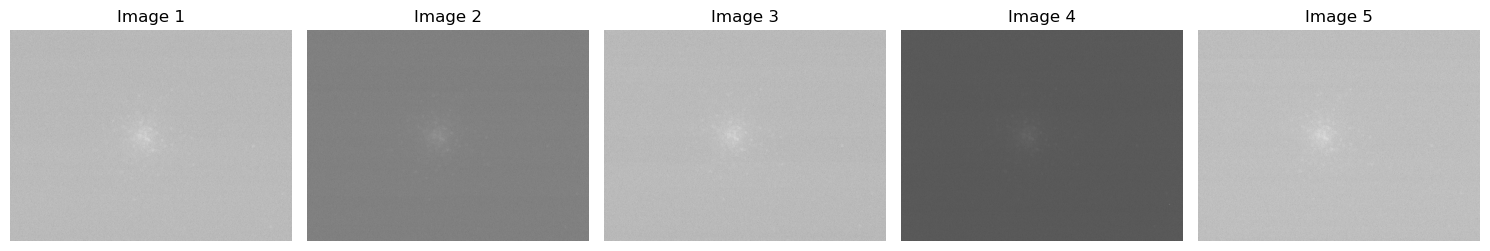

In [14]:
fig, axes =plt.subplots(1, 5, figsize=(15,4))

for i, ax in enumerate(axes):
    ax.imshow(data_list[i], origin="lower", cmap="gray")
    ax.set_title(f"Image {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

C:\Users\andyj\AppData\Local\Temp\ipykernel_33812\1306348252.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


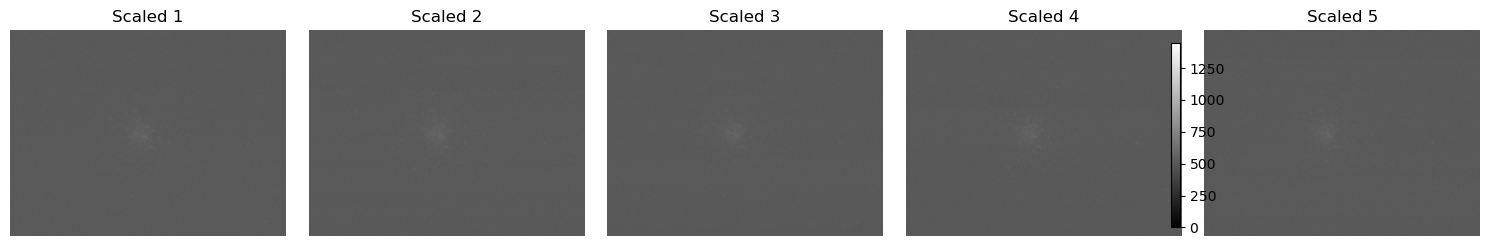

In [15]:
vmin = min(d.min() for d in data_list)
vmax = max(d.max() for d in data_list)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))

for i, ax in enumerate(axes):
    im = ax.imshow(data_list[i], origin="lower", cmap="gray",
                   vmin=vmin, vmax=vmax)
    ax.set_title(f"Scaled {i+1}")
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.tight_layout()
plt.show()

In [ ]:
"""
The main difference I find is that on the first subplots, the difference in gradients is evident
while for the second images it is harder to notice the diference, this can indicate that with
shared vmin and vmax one can compare the images directly, without a consistent scaling, 
images can look dimmer or brighter than others
"""

In [18]:
###3.3

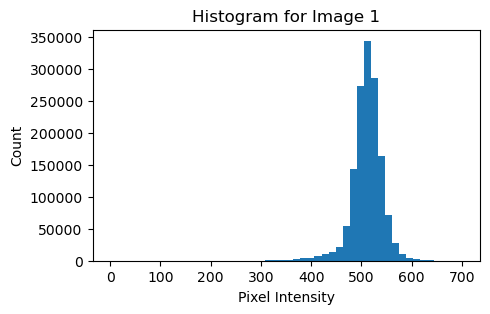

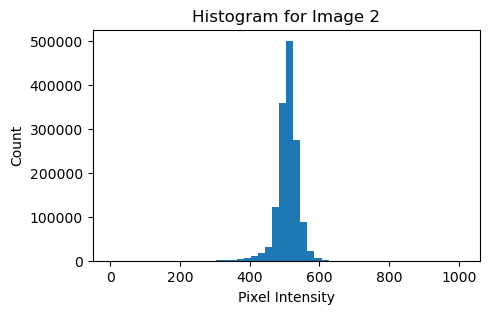

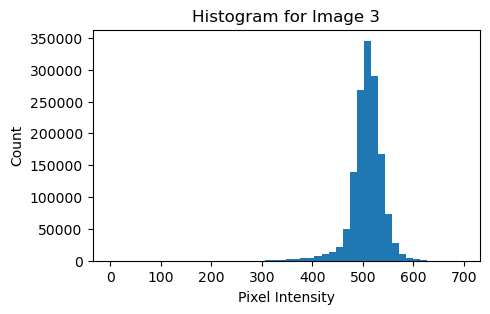

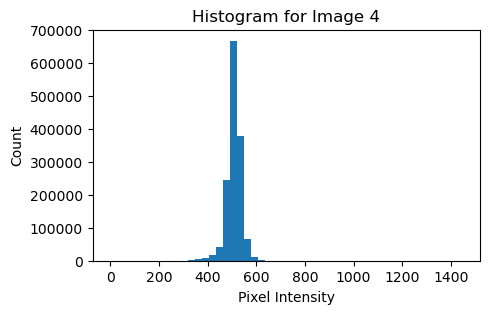

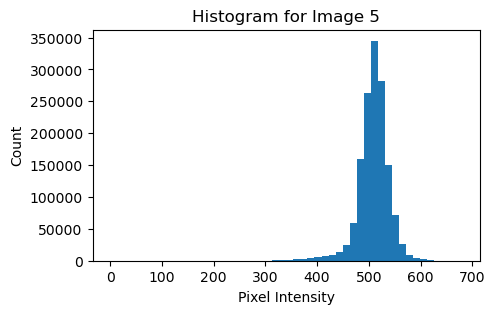

In [17]:
for i, data in enumerate(data_list):
    plt.figure(figsize=(5,3))
    plt.hist(data.ravel(), bins=50)
    plt.title(f"Histogram for Image {i+1}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Count")
    plt.show()

In [ ]:
"""
a) x axis: pixel intensity values
b) y-axis: number of pixels with that intensity
c) bins=50: divides range into 50 buckets
d) most data is centered at the low-intensity end, dark background
e) median

    1. 500
    2. 500
    3. 500
    4. around 500
    5. around 500
"""

### 3.4

In [20]:
combined_image = np.median(np.array(data_list), axis=0)
print("Combined median pixel value:", np.median(combined_image))


Combined median pixel value: 510.0


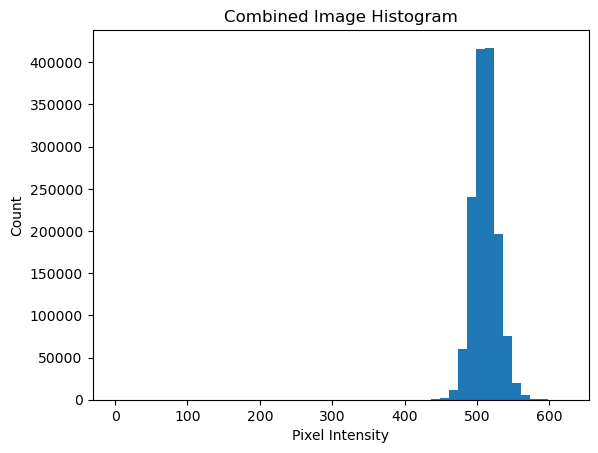

In [21]:
plt.hist(combined_image.ravel(), bins=50)
plt.title("Combined Image Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Count")
plt.show()

In [23]:
vmin = np.percentile(combined_image, 5)
vmax = np.percentile(combined_image, 95)

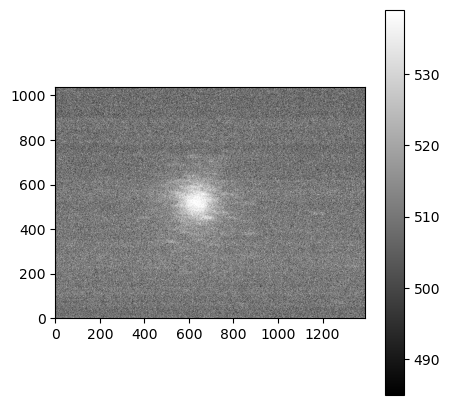

In [24]:
plt.figure(figsize=(5,5))
plt.imshow(combined_image, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
plt.colorbar()
plt.show()

In [ ]:
"""
This second image makes a clear distion between the star and its surrounding, 
meaning that the background is smoother, the noise is reduced and the faint structure becomes 
visible
"""

In [ ]:
#3.5

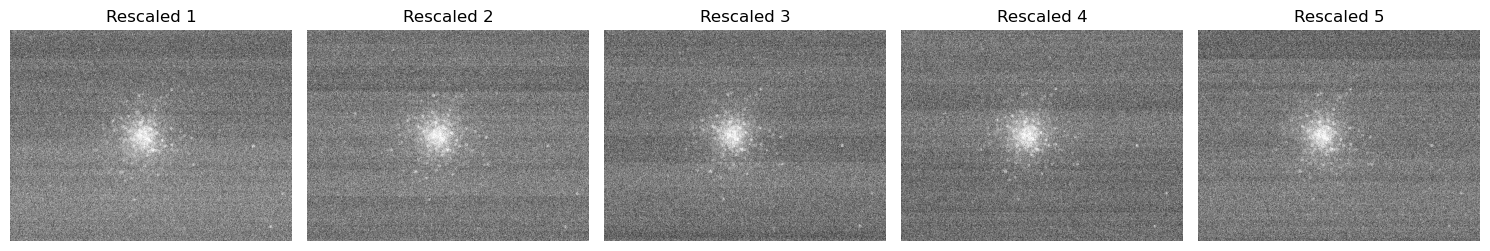

In [27]:
fig, axes = plt.subplots(1, 5, figsize=(15,4))

for i, ax in enumerate(axes):
    ax.imshow(data_list[i], origin="lower", cmap="gray",
              vmin=vmin, vmax=vmax)
    ax.set_title(f"Rescaled {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [29]:
fits.writeto("combined.fits", combined_image, overwrite=True)